## Import Libraries

In [16]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

## Load Data

In [2]:
# Load dataset
df = pd.read_csv("Loan_default.csv")

# Preview
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## Basic Info

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

## Data Cleaning

In [4]:
# Drop ID column
df.drop("LoanID", axis=1, inplace=True)

# Encode categorical variables
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus',
                    'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


## Feature Engineering

In [5]:
# Financial Stress Score
df['Financial_Stress'] = (
    (df['LoanAmount'] / df['Income']) +
    (df['InterestRate'] / 100) +
    df['DTIRatio']
)

# Employment Stability
df['Employment_Stability'] = df['MonthsEmployed'] / df['Age']

# Credit Category
def credit_bucket(x):
    if x > 750:
        return 2
    elif x > 650:
        return 1
    else:
        return 0

df['Credit_Category'] = df['CreditScore'].apply(credit_bucket)

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Financial_Stress,Employment_Stability,Credit_Category
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0,1.180562,1.428571,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0,3.195581,0.217391,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1,2.055854,0.565217,0
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0,1.713338,0.000000,1
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0,1.242279,0.133333,0


## Explorator Data Analysis

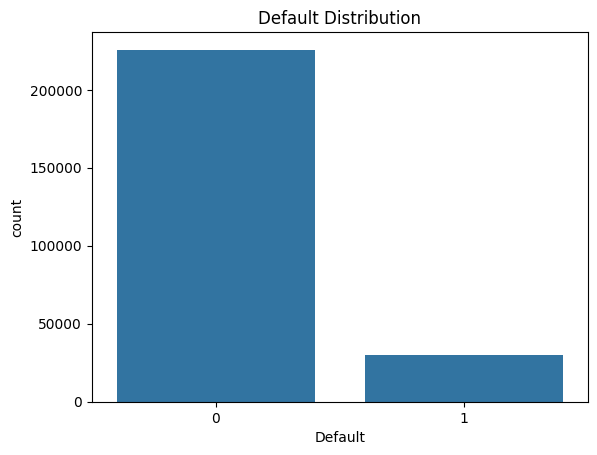

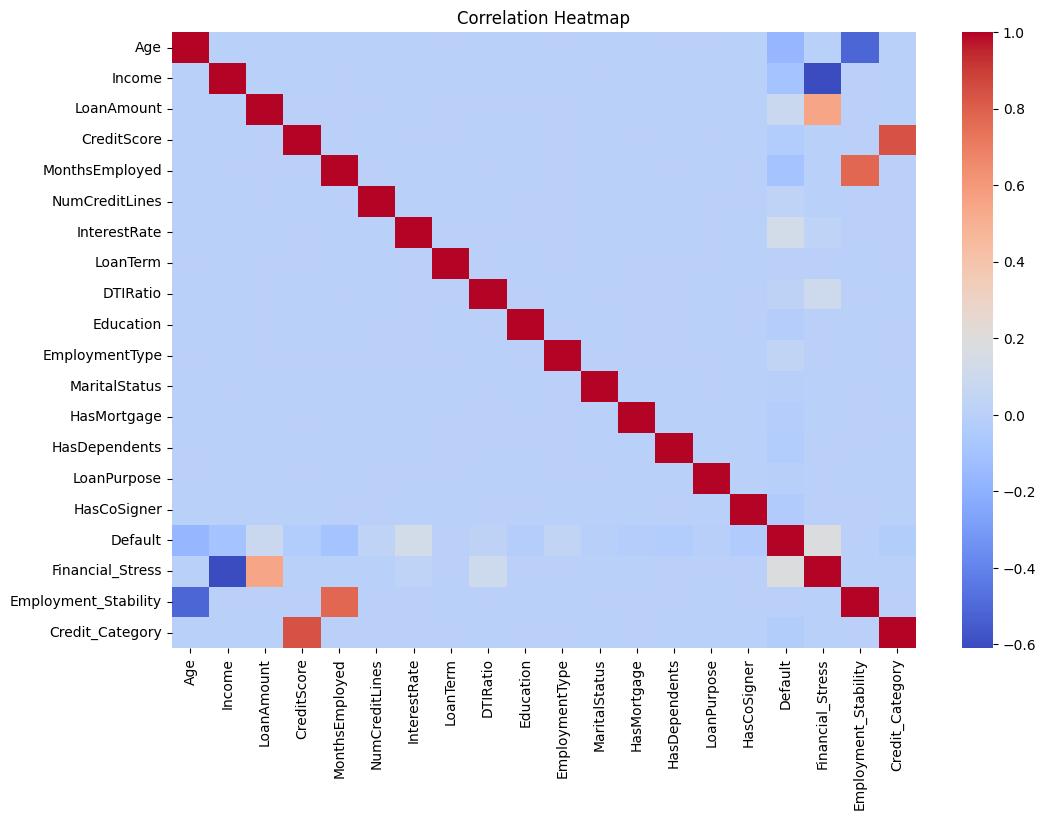

In [6]:
# Default distribution
sns.countplot(x='Default', data=df)
plt.title("Default Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Prepare Data For Model

In [7]:
X = df.drop('Default', axis=1)
y = df['Default']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build Model 1 (Logistic Regression)

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.8869786567456432


C:\Users\anand\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Build Model 2 (Random Forest)

In [9]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8869003328764441


## Model Evaluation


Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.62      0.06      0.10      5900

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.52     51070
weighted avg       0.86      0.89      0.84     51070



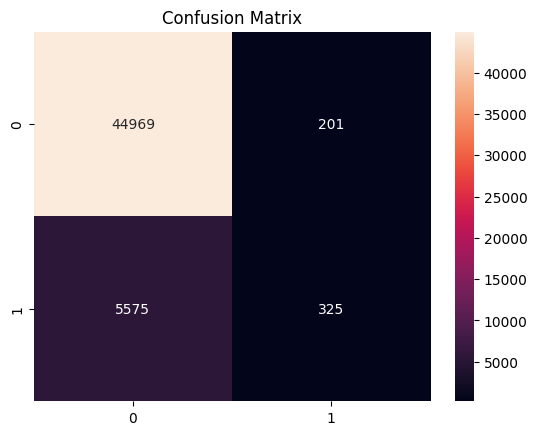

In [10]:
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## ROC-AUC Score

In [11]:
y_prob = rf.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.7342129657077031


## Cross Validation

In [17]:
cv_scores = cross_val_score(rf, X, y, cv=5)
print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.88568631 0.88680243 0.88546868 0.88535119 0.88503789]
Average CV Score: 0.8856693004024322


## Feature Importance

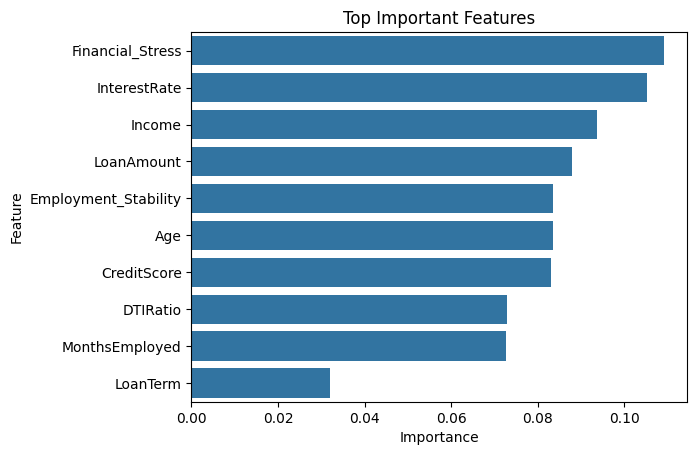

In [18]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top Important Features")
plt.show()

## Risk Scoring System

In [19]:
# Probability scores
risk_prob = model.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    'Risk_Probability': risk_prob
})

# Risk categorization
def risk_level(x):
    if x > 0.7:
        return "High Risk"
    elif x > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df['Risk_Level'] = risk_df['Risk_Probability'].apply(risk_level)

risk_df.head()

,Risk_Probability,Risk_Level
0,0.032985,Low Risk
1,0.045464,Low Risk
2,0.111458,Low Risk
3,0.103372,Low Risk
4,0.103111,Low Risk


## Early Warning System (Key Feature)

In [20]:
def early_warning(row):
    if row['DTIRatio'] > 0.5:
        return "High Debt Risk"
    elif row['CreditScore'] < 600:
        return "Low Credit Score"
    elif row['MonthsEmployed'] < 12:
        return "Unstable Job"
    else:
        return "Normal"

df['Warning_Flag'] = df.apply(early_warning, axis=1)

df[['DTIRatio','CreditScore','MonthsEmployed','Warning_Flag']].head()

,DTIRatio,CreditScore,MonthsEmployed,Warning_Flag
0,0.44,520,80,Low Credit Score
1,0.68,458,15,High Debt Risk
2,0.31,451,26,Low Credit Score
3,0.23,743,0,Unstable Job
4,0.73,633,8,High Debt Risk


## Visualization of Risk

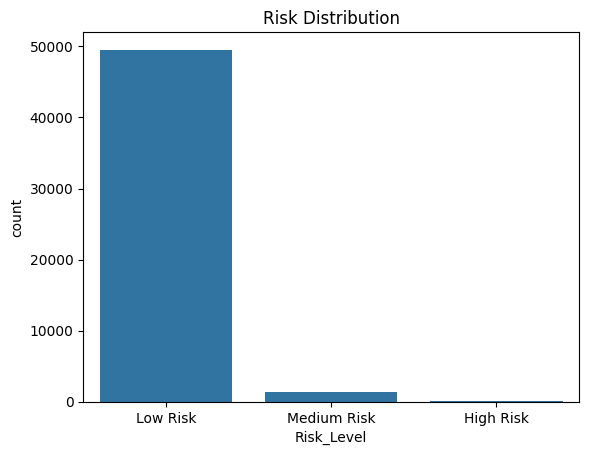

In [21]:
sns.countplot(x=risk_df['Risk_Level'])
plt.title("Risk Distribution")
plt.show()

## Business Insights (Print Output)

In [22]:
high_risk = risk_df[risk_df['Risk_Level'] == 'High Risk'].shape[0]
total = risk_df.shape[0]

print("BUSINESS INSIGHTS:\n")

print(f"High Risk Customers: {high_risk}/{total}")
print(f"Percentage: {(high_risk/total)*100:.2f}%\n")

print("KEY FINDINGS:")
print("- High DTI ratio strongly linked to defaults")
print("- Low credit score increases risk significantly")
print("- Short employment duration leads to higher default probability")

BUSINESS INSIGHTS:

High Risk Customers: 115/51070
Percentage: 0.23%

KEY FINDINGS:
- High DTI ratio strongly linked to defaults
- Low credit score increases risk significantly
- Short employment duration leads to higher default probability


## Business Recommendations

In [23]:
print("BUSINESS RECOMMENDATIONS:\n")

print("- Reduce loan approvals for high DTI customers")
print("- Monitor low credit score customers closely")
print("- Prefer applicants with stable employment")
print("- Implement early warning alerts before default")

BUSINESS RECOMMENDATIONS:

- Reduce loan approvals for high DTI customers
- Monitor low credit score customers closely
- Prefer applicants with stable employment
- Implement early warning alerts before default


## Final Statement

In [24]:
print("\nFINAL CONCLUSION:")
print("This system helps banks identify risky customers before default, enabling proactive risk management and reducing NPAs.")


FINAL CONCLUSION:
This system helps banks identify risky customers before default, enabling proactive risk management and reducing NPAs.


## Test Model With New Customer

In [25]:
sample = pd.DataFrame([{
    'Age': 30,
    'Income': 30000,
    'LoanAmount': 25000,
    'CreditScore': 580,
    'MonthsEmployed': 6,
    'NumCreditLines': 5,
    'InterestRate': 15,
    'LoanTerm': 36,
    'DTIRatio': 0.6,
    'Education': 1,
    'EmploymentType': 0,
    'MaritalStatus': 1,
    'HasMortgage': 1,
    'HasDependents': 1,
    'LoanPurpose': 2,
    'HasCoSigner': 0
}])

## Apply Feature Engineering To Sample

In [26]:
sample['Financial_Stress'] = (
    (sample['LoanAmount'] / sample['Income']) +
    (sample['InterestRate'] / 100) +
    sample['DTIRatio']
)

sample['Employment_Stability'] = sample['MonthsEmployed'] / sample['Age']

sample['Credit_Category'] = sample['CreditScore'].apply(credit_bucket)

## Predict

In [27]:
pred = rf.predict(sample)
prob = rf.predict_proba(sample)[:,1]

print("Prediction:", pred[0])
print("Probability:", prob[0])

Prediction: 0
Probability: 0.22


## Risk Levevl

In [28]:
print("Warning:", early_warning(sample.iloc[0]))